In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from collections import Counter
from imblearn.over_sampling import SMOTE

## 1. Exploratory Data Analysis (EDA)

In [19]:
# Load the dataset correctly from the 'glass' sheet, assuming the first row is the header.
df = pd.read_excel('/content/glass.xlsx', sheet_name='glass', header=0)

# Convert all feature columns to numeric, coercing errors to NaN.
# The 'Type' column should be integer.
for col in df.columns:
    if col != 'Type':
        df[col] = pd.to_numeric(df[col], errors='coerce')
    else:
        df[col] = df[col].astype(int)

print("Dataset loaded and dtypes corrected. Displaying the first 5 rows:")
display(df.head())

Dataset loaded and dtypes corrected. Displaying the first 5 rows:


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [20]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [21]:
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [22]:
print("\nChecking for missing values:")
display(df.isnull().sum())


Checking for missing values:


,0
RI,0
Na,0
Mg,0
Al,0
Si,0
K,0
Ca,0
Ba,0
Fe,0
Type,0


In [23]:
print("\nDistribution of Glass Types:")
display(df['Type'].value_counts())


Distribution of Glass Types:


,count
Type,
2,76
1,70
7,29
3,17
5,13
6,9


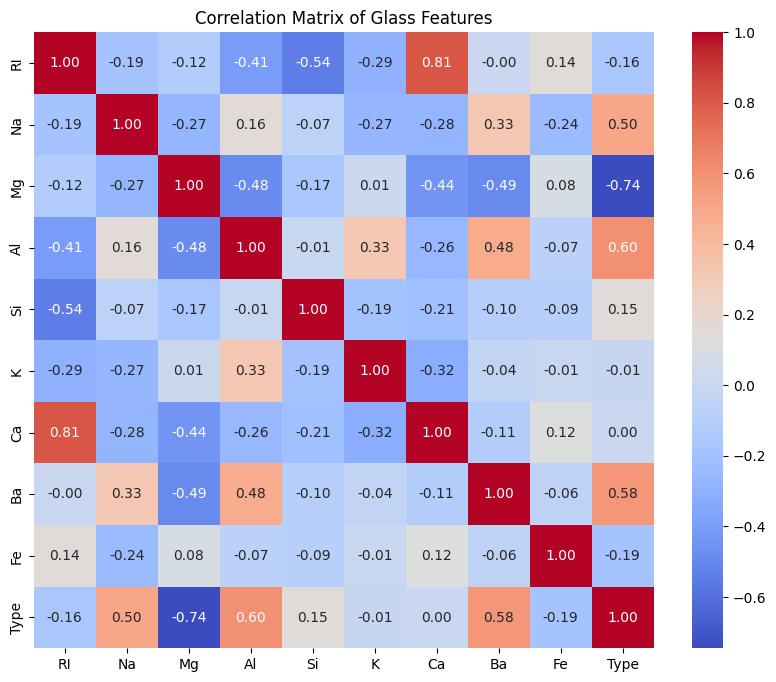

In [24]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Glass Features')
plt.show()

## 4: Random Forest Model Implementation

In [31]:
# Split data into training and testing sets
# X_resampled and y_resampled are from the SMOTE step, which are balanced
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Distribution of classes in y_train: {Counter(y_train)}")
print(f"Distribution of classes in y_test: {Counter(y_test)}")

Shape of X_train: (319, 9)
Shape of X_test: (137, 9)
Distribution of classes in y_train: Counter({1: 54, 7: 53, 6: 53, 5: 53, 2: 53, 3: 53})
Distribution of classes in y_test: Counter({5: 23, 7: 23, 6: 23, 3: 23, 2: 23, 1: 22})


In [32]:
# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest Model trained successfully.")

Random Forest Model trained successfully.


In [33]:
# Evaluate the Random Forest Model
y_pred_rf = rf_model.predict(X_test)

print("\nRandom Forest Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf, average='weighted', zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf, average='weighted', zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf, average='weighted', zero_division=0):.4f}")

print("\nConfusion Matrix (Random Forest):")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_rf)))

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf, zero_division=0))


Random Forest Classifier Performance:
Accuracy: 0.9051
Precision: 0.9073
Recall: 0.9051
F1-Score: 0.9036

Confusion Matrix (Random Forest):


,0,1,2,3,4,5
0,18,1,3,0,0,0
1,4,17,0,1,1,0
2,1,0,22,0,0,0
3,0,0,0,22,0,1
4,0,0,0,0,23,0
5,0,0,0,1,0,22



Classification Report (Random Forest):
              precision    recall  f1-score   support

           1       0.78      0.82      0.80        22
           2       0.94      0.74      0.83        23
           3       0.88      0.96      0.92        23
           5       0.92      0.96      0.94        23
           6       0.96      1.00      0.98        23
           7       0.96      0.96      0.96        23

    accuracy                           0.91       137
   macro avg       0.91      0.90      0.90       137
weighted avg       0.91      0.91      0.90       137



## 5: Bagging and Boosting Methods

In [34]:
# Implement Bagging (using BaggingClassifier with Decision Tree as base estimator)
bagging_model = BaggingClassifier(n_estimators=100, random_state=42)
bagging_model.fit(X_train, y_train)

y_pred_bagging = bagging_model.predict(X_test)

print("\nBagging Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_bagging):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_bagging, average='weighted', zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_bagging, average='weighted', zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_bagging, average='weighted', zero_division=0):.4f}")

print("\nConfusion Matrix (Bagging):")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_bagging)))

print("\nClassification Report (Bagging):")
print(classification_report(y_test, y_pred_bagging, zero_division=0))


Bagging Classifier Performance:
Accuracy: 0.8905
Precision: 0.8938
Recall: 0.8905
F1-Score: 0.8855

Confusion Matrix (Bagging):


,0,1,2,3,4,5
0,19,1,2,0,0,0
1,4,14,1,1,2,1
2,1,0,22,0,0,0
3,0,0,0,22,0,1
4,0,0,0,0,23,0
5,0,0,0,1,0,22



Classification Report (Bagging):
              precision    recall  f1-score   support

           1       0.79      0.86      0.83        22
           2       0.93      0.61      0.74        23
           3       0.88      0.96      0.92        23
           5       0.92      0.96      0.94        23
           6       0.92      1.00      0.96        23
           7       0.92      0.96      0.94        23

    accuracy                           0.89       137
   macro avg       0.89      0.89      0.89       137
weighted avg       0.89      0.89      0.89       137



In [35]:
# Implement Boosting (using AdaBoost Classifier with Decision Tree as base estimator)
adaboost_model = AdaBoostClassifier(n_estimators=100, random_state=42)
adaboost_model.fit(X_train, y_train)

y_pred_adaboost = adaboost_model.predict(X_test)

print("\nAdaBoost Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_adaboost):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_adaboost, average='weighted', zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_adaboost, average='weighted', zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_adaboost, average='weighted', zero_division=0):.4f}")

print("\nConfusion Matrix (AdaBoost):")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_adaboost)))

print("\nClassification Report (AdaBoost):")
print(classification_report(y_test, y_pred_adaboost, zero_division=0))


AdaBoost Classifier Performance:
Accuracy: 0.6131
Precision: 0.5809
Recall: 0.6131
F1-Score: 0.5566

Confusion Matrix (AdaBoost):


,0,1,2,3,4,5
0,16,4,2,0,0,0
1,17,0,0,5,0,1
2,20,1,2,0,0,0
3,0,0,0,22,0,1
4,0,0,0,0,23,0
5,0,0,0,2,0,21



Classification Report (AdaBoost):
              precision    recall  f1-score   support

           1       0.30      0.73      0.43        22
           2       0.00      0.00      0.00        23
           3       0.50      0.09      0.15        23
           5       0.76      0.96      0.85        23
           6       1.00      1.00      1.00        23
           7       0.91      0.91      0.91        23

    accuracy                           0.61       137
   macro avg       0.58      0.61      0.56       137
weighted avg       0.58      0.61      0.56       137



In [36]:
# Implement Boosting (using GradientBoosting Classifier)
gradient_boost_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gradient_boost_model.fit(X_train, y_train)

y_pred_gradient_boost = gradient_boost_model.predict(X_test)

print("\nGradient Boosting Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gradient_boost):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gradient_boost, average='weighted', zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_gradient_boost, average='weighted', zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_gradient_boost, average='weighted', zero_division=0):.4f}")

print("\nConfusion Matrix (Gradient Boosting):")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_gradient_boost)))

print("\nClassification Report (Gradient Boosting):")
print(classification_report(y_test, y_pred_gradient_boost, zero_division=0))


Gradient Boosting Classifier Performance:
Accuracy: 0.8686
Precision: 0.8695
Recall: 0.8686
F1-Score: 0.8670

Confusion Matrix (Gradient Boosting):


,0,1,2,3,4,5
0,14,2,5,0,1,0
1,3,18,2,0,0,0
2,2,0,20,0,1,0
3,0,1,0,22,0,0
4,0,0,0,0,23,0
5,0,0,0,1,0,22



Classification Report (Gradient Boosting):
              precision    recall  f1-score   support

           1       0.74      0.64      0.68        22
           2       0.86      0.78      0.82        23
           3       0.74      0.87      0.80        23
           5       0.96      0.96      0.96        23
           6       0.92      1.00      0.96        23
           7       1.00      0.96      0.98        23

    accuracy                           0.87       137
   macro avg       0.87      0.87      0.87       137
weighted avg       0.87      0.87      0.87       137



## Additional Notes

### 1. Explain Bagging and Boosting methods. How is it different from each other.

Both Bagging and Boosting are ensemble learning techniques that combine multiple models to improve predictive performance and reduce overfitting. They differ primarily in how they build and combine these models:

**Bagging (Bootstrap Aggregating):**
*   **Concept:** Bagging involves training multiple models (typically of the same type, like Decision Trees) independently on different subsets of the training data. Each subset is created by **bootstrap sampling** (sampling with replacement) from the original dataset. The final prediction is made by averaging (for regression) or majority voting (for classification) the predictions of all individual models.
*   **Goal:** Primarily aims to reduce **variance** in the model, making it less sensitive to the specific training data. By averaging predictions from models trained on different subsets, the impact of individual noisy predictions is reduced.
*   **Parallelism:** Since each model is trained independently, bagging can be easily parallelized.
*   **Example:** Random Forest is a prominent example of a bagging algorithm, where multiple decision trees are trained on bootstrapped samples, and their predictions are aggregated.

**Boosting:**
*   **Concept:** Boosting also combines multiple weak learners (models that perform slightly better than random guessing) sequentially. However, unlike bagging, boosting trains models **iteratively**. Each subsequent model is trained to correct the errors of the previous models. It typically focuses more on misclassified data points from previous iterations.
*   **Goal:** Primarily aims to reduce **bias** and to a lesser extent, variance. By iteratively focusing on errors, boosting can produce a strong learner from a sequence of weak learners.
*   **Sequential Nature:** Due to its iterative nature, boosting is inherently sequential and generally cannot be parallelized to the same extent as bagging.
*   **Examples:** AdaBoost, Gradient Boosting Machines (GBM), XGBoost, LightGBM, and CatBoost are popular boosting algorithms.

**Key Differences Summarized:**

| Feature           | Bagging                                      | Boosting                                       |
| :---------------- | :------------------------------------------- | :--------------------------------------------- |
| **Model Training**  | Independent, parallel                        | Sequential, iterative                          |
| **Data Sampling**   | Bootstrap samples (with replacement)         | Weights misclassified samples more              |
| **Focus**         | Reduces Variance                             | Reduces Bias                                   |
| **Weak Learners**   | Strong learners (e.g., full Decision Trees)   | Weak learners (e.g., shallow Decision Trees)  |
| **Final Prediction**| Averaging/Majority Voting                     | Weighted averaging of sequential predictions  |
| **Example**       | Random Forest                                | AdaBoost, Gradient Boosting, XGBoost            |

### 2. Explain how to handle imbalance in the data.

Handling imbalanced data is crucial in machine learning when the number of observations in one class significantly outweighs the number of observations in other classes. If not addressed, models can become biased towards the majority class, leading to poor predictive performance on the minority class, which is often the class of interest (e.g., fraud detection, disease prediction).

Here are common strategies to handle imbalanced data:

1.  **Resampling Techniques:**
    *   **Oversampling Minority Class:**
        *   **Random Oversampling:** Duplicates random instances of the minority class to balance the class distribution. While simple, it can lead to overfitting.
        *   **SMOTE (Synthetic Minority Over-sampling Technique):** Creates synthetic (new, not just copied) samples of the minority class. It works by taking a sample from the minority class, finding its k-nearest neighbors, and then generating new samples along the line segments connecting the sample to its neighbors. This was used in our preprocessing step.
        *   **ADASYN (Adaptive Synthetic Sampling):** Similar to SMOTE, but it focuses on generating synthetic samples for minority class instances that are harder to learn (i.e., those that are surrounded by majority class instances).
    *   **Undersampling Majority Class:**
        *   **Random Undersampling:** Randomly removes instances from the majority class until the classes are balanced. This can lead to loss of potentially valuable information from the majority class.
        *   **Tomek Links:** Identifies pairs of samples from different classes that are very close to each other. It removes the majority class sample from the pair, effectively cleaning the decision boundary.
        *   **Edited Nearest Neighbors (ENN):** Removes samples whose class label differs from the majority class among its k-nearest neighbors. This removes noisy or ambiguous samples.

2.  **Algorithmic Approaches:**
    *   **Cost-Sensitive Learning:** Modify the learning algorithm itself to assign a higher misclassification cost to the minority class. This makes the model pay more attention to correctly classifying the minority class. Many algorithms (e.g., Support Vector Machines, Decision Trees, Logistic Regression) have parameters like `class_weight` that can be adjusted.
    *   **Ensemble Methods:** Some ensemble methods are inherently good at handling imbalance or can be adapted:
        *   **Bagging-based methods (like Balanced Random Forest):** Build individual trees on balanced bootstrap samples.
        *   **Boosting-based methods:** Can sometimes handle imbalance as they sequentially focus on misclassified samples, but explicit adjustments (e.g., custom loss functions, weighted samples) might still be beneficial.

3.  **Evaluation Metrics:**
    *   When dealing with imbalanced data, accuracy alone is not a reliable metric. Instead, focus on metrics that provide a more nuanced view of performance, especially for the minority class:
        *   **Precision:** The proportion of positive identifications that were actually correct.
        *   **Recall (Sensitivity):** The proportion of actual positives that were identified correctly.
        *   **F1-Score:** The harmonic mean of precision and recall, providing a single score that balances both.
        *   **Confusion Matrix:** Provides a detailed breakdown of true positives, true negatives, false positives, and false negatives.
        *   **ROC AUC (Receiver Operating Characteristic - Area Under the Curve):** Measures the ability of a classifier to distinguish between classes. A higher AUC indicates a better model performance.

**Choosing a Strategy:** The best strategy often depends on the specific dataset, the degree of imbalance, and the domain problem. It's common to experiment with a combination of techniques and thoroughly evaluate models using appropriate metrics.

## 2. Data Visualization


Histograms of Features:


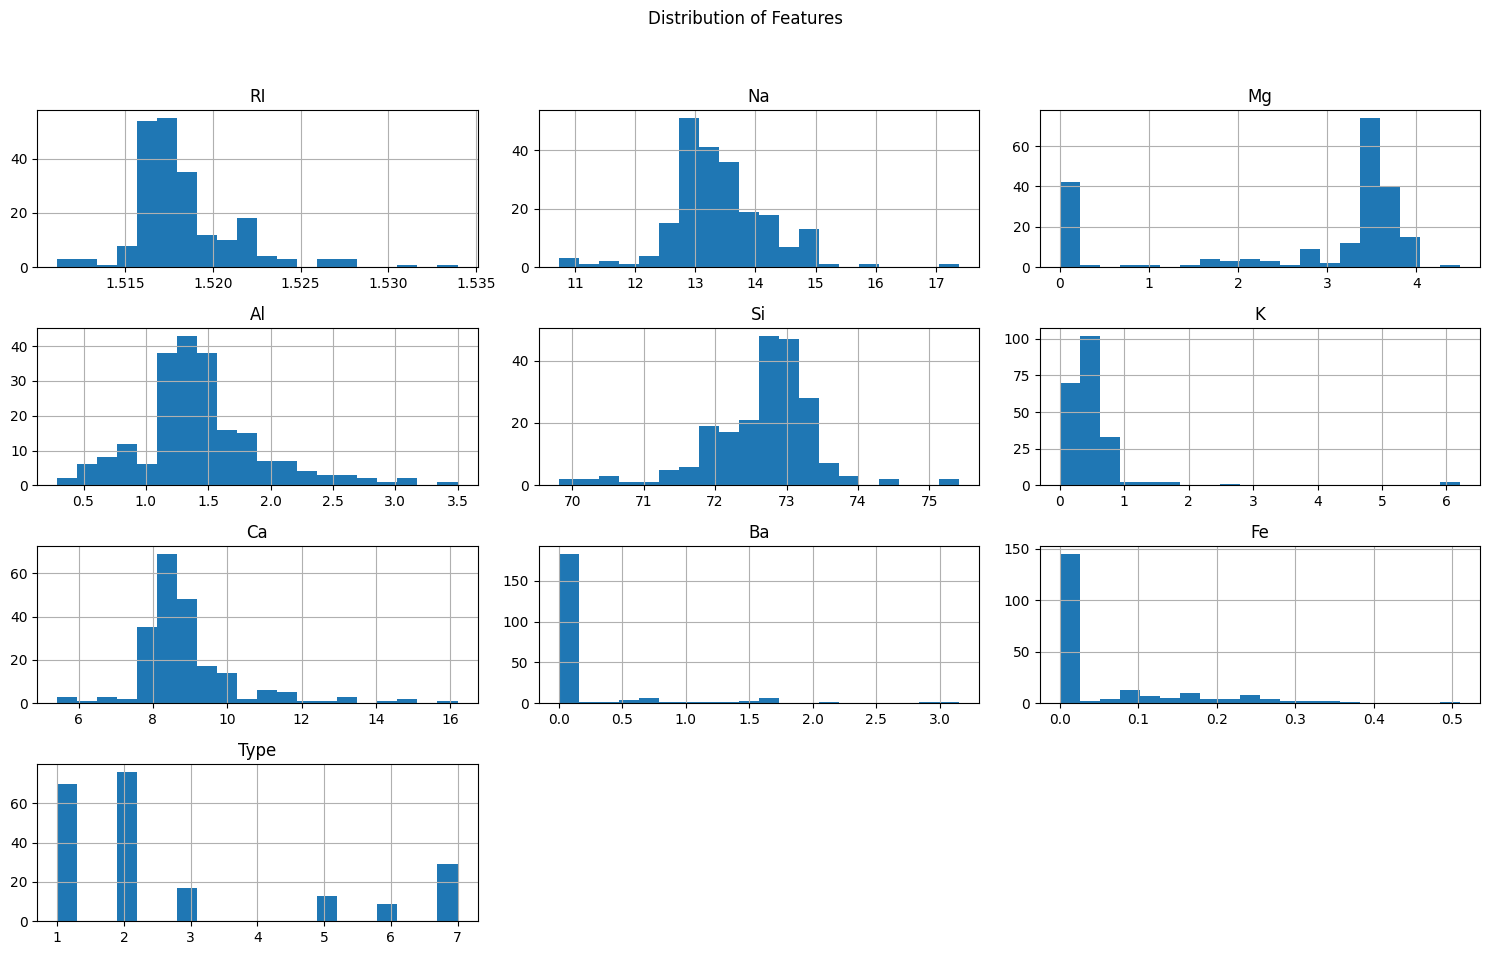

In [25]:
print("\nHistograms of Features:")
df.hist(figsize=(15, 10), bins=20)
plt.suptitle('Distribution of Features')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Box Plots of Features (checking for outliers):


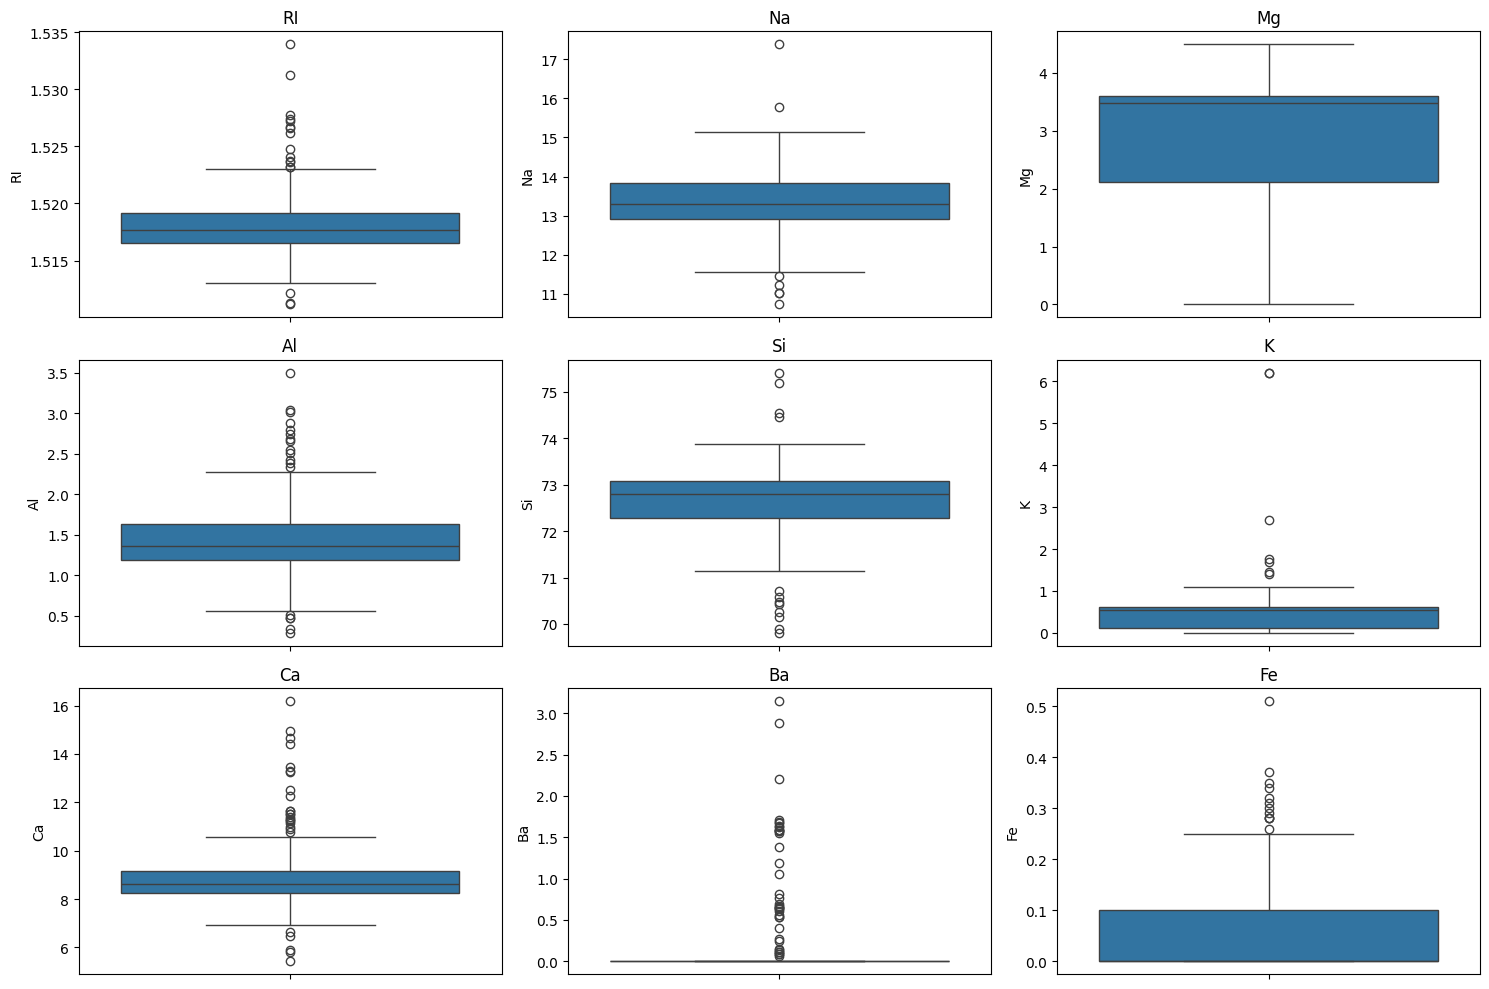

In [26]:
print("\nBox Plots of Features (checking for outliers):")
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.columns[:-1]): # Exclude 'Type' column
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of features
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [27]:
print("\n### Handling Missing Values (already checked, no missing values found):")
print(df.isnull().sum())


### Handling Missing Values (already checked, no missing values found):
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


In [28]:
print("\n### Handling Categorical Variables (no categorical features, 'Type' is target variable):")
print("All feature columns are numeric. The 'Type' column is the target variable and is integer type.")


### Handling Categorical Variables (no categorical features, 'Type' is target variable):
All feature columns are numeric. The 'Type' column is the target variable and is integer type.


In [29]:
print("\n### Feature Scaling (Standardization):")
# Separate features (X) and target (y)
X = df.drop('Type', axis=1)
y = df['Type']

# Initialize StandardScaler
scaler = StandardScaler()

# Apply standardization to features
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Features standardized. Displaying first 5 rows of scaled data:")
display(X_scaled_df.head())


### Feature Scaling (Standardization):
Features standardized. Displaying first 5 rows of scaled data:


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,0.872868,0.284953,1.254639,-0.692442,-1.127082,-0.671705,-0.145766,-0.352877,-0.586451
1,-0.249333,0.591817,0.636168,-0.170460,0.102319,-0.026213,-0.793734,-0.352877,-0.586451
2,-0.721318,0.149933,0.601422,0.190912,0.438787,-0.164533,-0.828949,-0.352877,-0.586451
3,-0.232831,-0.242853,0.698710,-0.310994,-0.052974,0.112107,-0.519052,-0.352877,-0.586451
4,-0.312045,-0.169205,0.650066,-0.411375,0.555256,0.081369,-0.624699,-0.352877,-0.586451


In [30]:
print("\n### Handling Imbalanced Data (using SMOTE):")
print(f"Original target variable distribution: {Counter(y)}")

smt = SMOTE(random_state=42)
X_resampled, y_resampled = smt.fit_resample(X_scaled_df, y)

print(f"Resampled target variable distribution: {Counter(y_resampled)}")



### Handling Imbalanced Data (using SMOTE):
Original target variable distribution: Counter({2: 76, 1: 70, 7: 29, 3: 17, 5: 13, 6: 9})
Resampled target variable distribution: Counter({1: 76, 2: 76, 3: 76, 5: 76, 6: 76, 7: 76})


In [8]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 1 columns):
 #   Column                                                        Non-Null Count  Dtype 
---  ------                                                        --------------  ----- 
 0   Prepare a model for glass classification using Random Forest  18 non-null     object
dtypes: object(1)
memory usage: 284.0+ bytes


In [9]:
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,Prepare a model for glass classification using Random Forest
count,18
unique,18
top,Data Description:
freq,1


In [10]:
print("\nChecking for missing values:")
display(df.isnull().sum())


Checking for missing values:


,0
Prepare a model for glass classification using Random Forest,1


In [37]:
print("\nDistribution of Glass Types:")
display(df['Type'].value_counts())


Distribution of Glass Types:


,count
Type,
2,76
1,70
7,29
3,17
5,13
6,9


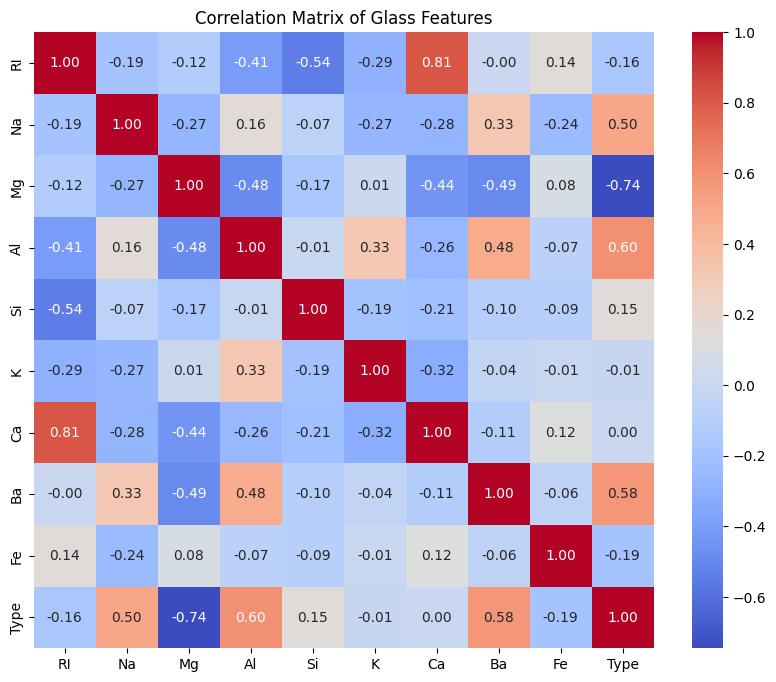

In [38]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Glass Features')
plt.show()

In [39]:
xl = pd.ExcelFile('/content/glass.xlsx')
print("Sheet names in glass.xlsx:", xl.sheet_names)

Sheet names in glass.xlsx: ['Description', 'glass']
